# Original two-factor VaDE: neural architecture and hyperparameter grid

This notebook organizes and reports a **neural-only search of the original model**. It does not use the shared-$w$ extension. Existing notebooks and model definitions remain available.

`NeuralVaDE` inherits the original prior, loss, reparameterization, mixture responsibilities, category marginals, and interaction penalty without overriding them. Only hidden-layer sizes/depth and activation are configurable. Tests check method identity and exact ReLU equivalence for the same seed.

## 1. Search scope and protocol

| Searched | Grid |
|---|---|
| Encoder hidden widths (decoder mirrored) | `(64,)`, `(128,128)`, `(128,128,128)` |
| Hidden activation | ReLU, tanh |
| Adam learning rate | `0.0003`, `0.001` |
| Minibatch size | `256`, `1024` |

The 24 Cartesian combinations are supplemented by the original `(128,128), ReLU, lr=0.001, batch=512` control, giving **25 screening trials**. The control is named `c000`.

**Fixed:** the five acoustic inputs and preprocessing; selected ten speakers and all their tokens; 80/10/10 token split; continuous latent dimension 8; 5 × 10 Gaussian components; diagonal covariance family; uniform factorized category priors; original VaDE-style loss; reconstruction variance 0.1; interaction weight 10; 4/32 training/evaluation MC samples; 20-epoch autoencoder and residual-KMeans initialization; Adam weight decay zero. No new continuous variable, supervision term, MI reward, or KL schedule is introduced.

1. Screen every candidate for up to 30 epochs (patience 10), using seed 42 and every training row.
2. Rank by $\sqrt{\mathrm{accuracy}_{phoneme,val}\,\mathrm{accuracy}_{speaker,val}}$. Hungarian label mappings use training labels only. Within each trial, the checkpoint still minimizes **unsupervised validation loss**.
3. Train the two highest-ranked non-control candidates plus the control from scratch for up to 100 epochs, at seeds 42, 43 and 44 (nine confirmation runs).
4. Select the configuration with highest mean validation score across these seeds; the control can win. Save that choice before accessing test predictions.
5. Evaluate only the selected configuration and control on test, at all confirmation seeds. No best test seed is selected.

This is a staged budgeted grid, not a claim that all 25 configurations were fully optimized. Validation labels guide hyperparameter selection, so selection is label-informed even though model gradients are unsupervised. Fixed epochs imply different numbers of optimizer steps for different batch sizes.

In [1]:
from pathlib import Path
import sys
from dataclasses import asdict
from pprint import pprint

ROOT = Path.cwd().resolve()
if not (ROOT / 'metadata_vowels_acoustics.csv').exists():
    ROOT = ROOT.parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))

from src.search_config import load_search_config, grid_candidates
CONFIG_PATH = ROOT / 'src' / 'configs' / 'neural_grid.py'
search = load_search_config(CONFIG_PATH)
print('Anaconda interpreter:', sys.executable)
pprint(asdict(search))
print('Screening configurations:', len(grid_candidates(search)))

Anaconda interpreter: C:\Users\46021\.conda\envs\lffl\python.exe
{'base': {'data': {'csv_path': 'metadata_vowels_acoustics.csv',
                   'features': ('f0_median_hz',
                                'f1_hz',
                                'f2_hz',
                                'f3_hz',
                                'duration_s'),
                   'log_features': False,
                   'n_speakers': 10,
                   'seed': 2026,
                   'speaker_ids': None,
                   'split': (0.8, 0.1, 0.1)},
          'knn_neighbors': 15,
          'methods': ('gmvae', 'knn', 'classifier'),
          'model': {'eval_mc_samples': 32,
                    'hidden_dims': (128, 128),
                    'interaction_weight': 10.0,
                    'latent_dim': 8,
                    'learn_mixture_weights': False,
                    'observation_variance': 0.1,
                    'train_mc_samples': 4},
          'output_dir': 'outputs/vowels',
         

## 2. Run a new search or load/resume this one

Use the `lffl` Anaconda interpreter. The cell launches the CLI in that same environment so worker processes behave consistently on Windows and on a server.

The saved path below loads/resumes the completed run delivered with this notebook. Set `RESUME_RUN = None` to run a **new** search after editing `src/configs/neural_grid.py`. Changing the config, dataset or algorithm source invalidates resume, preventing mixed experiments. The source hashes and full search plan are saved before any screening results.

Only train/validation arrays are passed to search workers. The test partition is used once the validation choice is fixed in `selection.json`. Training logs, per-epoch histories, checkpoints, and validation metrics are retained for every trial. Two worker processes use one numerical thread each; this is local process parallelism, not distributed training.

In [2]:
import subprocess

RESUME_RUN = ROOT / 'outputs' / 'neural_grid' / '20260924_225129_ccc857'
# RESUME_RUN = None  # Start a fresh grid after editing the config.
if RESUME_RUN is not None and not RESUME_RUN.exists():
    raise FileNotFoundError('Saved search not present. Set RESUME_RUN = None to run a new search.')
command = [sys.executable, str(ROOT / 'src' / 'train_grid.py'), '--config', str(CONFIG_PATH)]
if RESUME_RUN is not None:
    command += ['--resume', str(RESUME_RUN)]
with subprocess.Popen(command, cwd=ROOT, stdout=subprocess.PIPE, stderr=subprocess.STDOUT,
                      text=True, encoding='utf-8', errors='replace') as process:
    run_dir = RESUME_RUN
    for line in process.stdout:
        print(line, end='')
        if line.startswith('GRID DIRECTORY: '):
            run_dir = Path(line.split(': ', 1)[1].strip())
    if process.wait() != 0:
        raise RuntimeError('Search failed; inspect the logs and resume after resolving the problem.')
assert run_dir is not None and (run_dir / 'complete.json').exists()
print('Complete search:', run_dir)

Search already complete: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\neural_grid\20260924_225129_ccc857


Complete search: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\neural_grid\20260924_225129_ccc857


## 3. Verify the recorded scope and data

The original statistical model settings are explicitly checked against the baseline before searching. This cell inspects the recorded plan rather than relying on a potentially edited current config.

In [3]:
import json
import numpy as np
import pandas as pd
from IPython.display import display, Image

plan = json.loads((run_dir / 'plan.json').read_text(encoding='utf-8'))
data_info = json.loads((run_dir / 'data.json').read_text(encoding='utf-8'))
print('Speakers:', data_info['speakers'])
print('All selected rows:', data_info['selected_rows'])
print('Split:', data_info['split_counts'])
print('Fixed model settings:', plan['search']['base']['model'])
display(pd.DataFrame(plan['candidates']))

import joblib
worker_data = joblib.load(run_dir / 'train_val.joblib')
assert set(worker_data['x']) == set(worker_data['y']) == {'train', 'val'}
print('Search cache contains no test arrays.')

Speakers: ['jvs003', 'jvs009', 'jvs018', 'jvs036', 'jvs037', 'jvs038', 'jvs046', 'jvs061', 'jvs065', 'jvs078']
All selected rows: 46083
Split: {'train': 36866, 'val': 4608, 'test': 4609}
Fixed model settings: {'hidden_dims': [128, 128], 'latent_dim': 8, 'interaction_weight': 10.0, 'observation_variance': 0.1, 'train_mc_samples': 4, 'eval_mc_samples': 32, 'learn_mixture_weights': False}


,candidate_id,hidden_dims,activation,learning_rate,batch_size
0,c000,"[128, 128]",relu,0.0010,512
1,c001,[64],relu,0.0003,256
2,c002,[64],relu,0.0003,1024
3,c003,[64],relu,0.0010,256
4,c004,[64],relu,0.0010,1024
5,c005,[64],tanh,0.0003,256
6,c006,[64],tanh,0.0003,1024
7,c007,[64],tanh,0.0010,256
8,c008,[64],tanh,0.0010,1024
9,c009,"[128, 128]",relu,0.0003,256


Search cache contains no test arrays.


## 4. Screening leaderboard and architectural trade-offs

These are **validation results**, not test results. A larger network or smaller loss does not necessarily recover better phoneme/speaker categories. The geometric score gives both recognition targets equal multiplicative importance; individual accuracies remain visible.

,candidate_id,hidden_dims,activation,learning_rate,batch_size,val_phoneme_accuracy,val_speaker_accuracy,validation_score,best_epoch,elapsed_seconds
0,c022,"(128, 128, 128)",tanh,0.0003,1024,0.548828,0.217882,0.345803,30,81.325203
1,c024,"(128, 128, 128)",tanh,0.0010,1024,0.537109,0.211806,0.337287,30,80.271003
2,c005,"(64,)",tanh,0.0003,256,0.470052,0.227431,0.326962,30,71.412689
3,c008,"(64,)",tanh,0.0010,1024,0.493490,0.205946,0.318798,30,59.339315
4,c021,"(128, 128, 128)",tanh,0.0003,256,0.475260,0.200521,0.308706,29,98.676941
5,c014,"(128, 128)",tanh,0.0003,1024,0.481120,0.183811,0.297380,30,71.294949
6,c003,"(64,)",relu,0.0010,256,0.373047,0.227865,0.291555,30,72.346195
7,c007,"(64,)",tanh,0.0010,256,0.397569,0.212891,0.290927,30,71.060238
8,c011,"(128, 128)",relu,0.0010,256,0.380642,0.220052,0.289415,29,89.629674
9,c010,"(128, 128)",relu,0.0003,1024,0.430990,0.193359,0.288680,30,76.495236


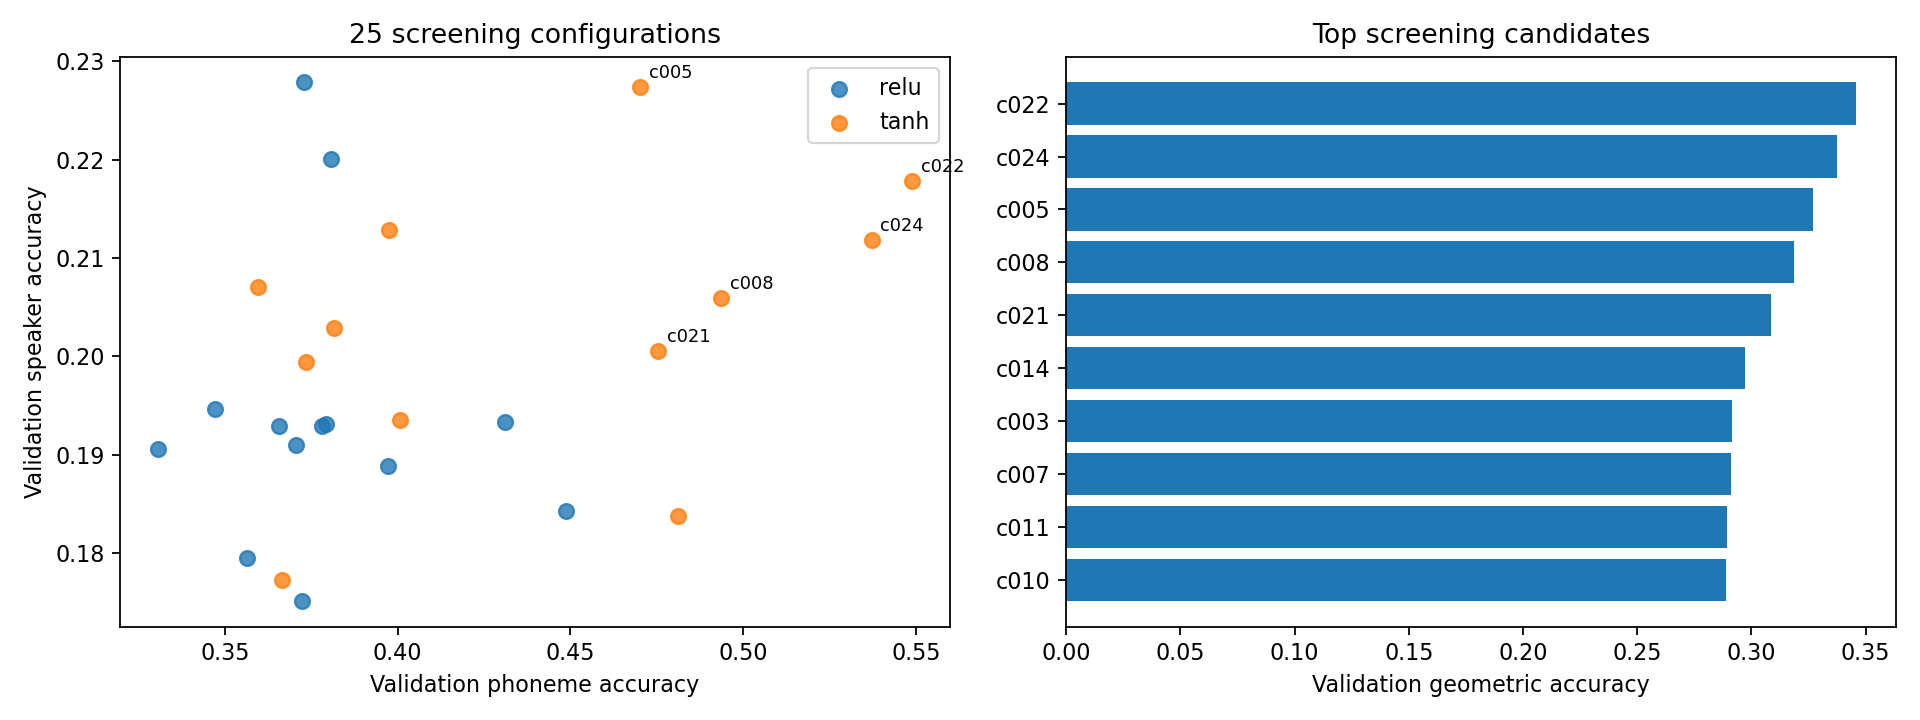

In [4]:
screen = pd.read_csv(run_dir / 'screen_leaderboard.csv').sort_values('validation_score', ascending=False)
display(screen[['candidate_id', 'hidden_dims', 'activation', 'learning_rate', 'batch_size',
                'val_phoneme_accuracy', 'val_speaker_accuracy', 'validation_score',
                'best_epoch', 'elapsed_seconds']])

import matplotlib
matplotlib.use('Agg')
import matplotlib.pyplot as plt
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))
for activation, group in screen.groupby('activation'):
    axes[0].scatter(group.val_phoneme_accuracy, group.val_speaker_accuracy, label=activation, s=45, alpha=0.8)
for _, row in screen.head(5).iterrows():
    axes[0].annotate(row.candidate_id, (row.val_phoneme_accuracy, row.val_speaker_accuracy), xytext=(4, 4), textcoords='offset points', fontsize=8)
axes[0].set(xlabel='Validation phoneme accuracy', ylabel='Validation speaker accuracy', title='25 screening configurations')
axes[0].legend()
top = screen.head(10).iloc[::-1]
axes[1].barh(top.candidate_id, top.validation_score)
axes[1].set(xlabel='Validation geometric accuracy', title='Top screening candidates')
fig.tight_layout()
fig.savefig(run_dir / 'screening.png', dpi=160)
plt.close(fig)
display(Image(filename=str(run_dir / 'screening.png')))

## 5. Multi-seed confirmation and committed selection

Confirmation retrains the shortlist and control from scratch with the same 100-epoch allowance. The control is retrained under the same numerical-thread settings as candidates; the historical single-seed result is only a reference. Seed variability is part of the result, rather than a reason to choose whichever seed happens to look best.

In [5]:
confirm = pd.read_csv(run_dir / 'confirm_leaderboard.csv')
ranking = pd.read_csv(run_dir / 'confirmation_ranking.csv')
selection = json.loads((run_dir / 'selection.json').read_text(encoding='utf-8'))
assert selection['test_accessed_during_selection'] is False
print('Validation-selected configuration:')
pprint(selection['winner'])
display(ranking)
display(confirm[['candidate_id', 'seed', 'val_phoneme_accuracy', 'val_speaker_accuracy', 'validation_score', 'best_epoch']].sort_values(['candidate_id', 'seed']))

Validation-selected configuration:
{'activation': 'tanh',
 'batch_size': 1024,
 'candidate_id': 'c022',
 'hidden_dims': [128, 128, 128],
 'learning_rate': 0.0003}


,candidate_id,mean_validation_score,std_validation_score,mean_val_phoneme_accuracy,mean_val_speaker_accuracy
0,c022,0.312741,0.017058,0.478154,0.205150
1,c024,0.294432,0.026165,0.416811,0.208984
2,c000,0.271564,0.067121,0.396123,0.187355


,candidate_id,seed,val_phoneme_accuracy,val_speaker_accuracy,validation_score,best_epoch
0,c000,42,0.556424,0.218967,0.349054,91
7,c000,43,0.318142,0.172309,0.234134,98
8,c000,44,0.313802,0.170790,0.231504,100
1,c022,42,0.542318,0.203776,0.332432,97
3,c022,43,0.459201,0.200304,0.303282,97
4,c022,44,0.432943,0.211372,0.302509,95
2,c024,42,0.496962,0.210720,0.323605,100
6,c024,43,0.380425,0.195964,0.273038,91
5,c024,44,0.373047,0.220269,0.286654,96


## 6. Held-out comparison across seeds

Results below use the same test tokens. Report both the mean and variability across seeds and paired differences against the control; do not select a best test seed. 'Significant' should not be inferred merely because one seed improved. Three seeds provide a limited stability check, not a conclusive significance test.

This is also an **exploratory** comparison: this test set has already appeared in earlier model comparisons. Tokens can share recordings across train/test, and these ten speakers are present in every partition. A fresh recording-grouped evaluation would be needed for a stronger generalization claim.

,candidate_id,seed,phoneme_accuracy,speaker_accuracy,joint_accuracy
0,c000,42,0.566717,0.215882,0.125624
1,c000,43,0.320894,0.168583,0.045129
2,c000,44,0.304404,0.158820,0.046865
3,c022,42,0.558690,0.202213,0.119983
4,c022,43,0.470818,0.185073,0.093296
5,c022,44,0.446518,0.200694,0.092862


phoneme_accuracy           speaker_accuracy            \
                         mean       std             mean       std   
candidate_id                                                         
c000                 0.397339  0.146918         0.181095  0.030519   
c022                 0.492008  0.059012         0.195993  0.009488   

             joint_accuracy            
                       mean       std  
candidate_id                           
c000               0.072539  0.045981  
c022               0.102047  0.015534

,phoneme_accuracy,speaker_accuracy,joint_accuracy
seed,,,
42,-0.802777,-1.366891,-0.564114
43,14.992406,1.648948,4.816663
44,14.211326,4.187459,4.599696


Paired differences above are percentage points: selected configuration minus control.


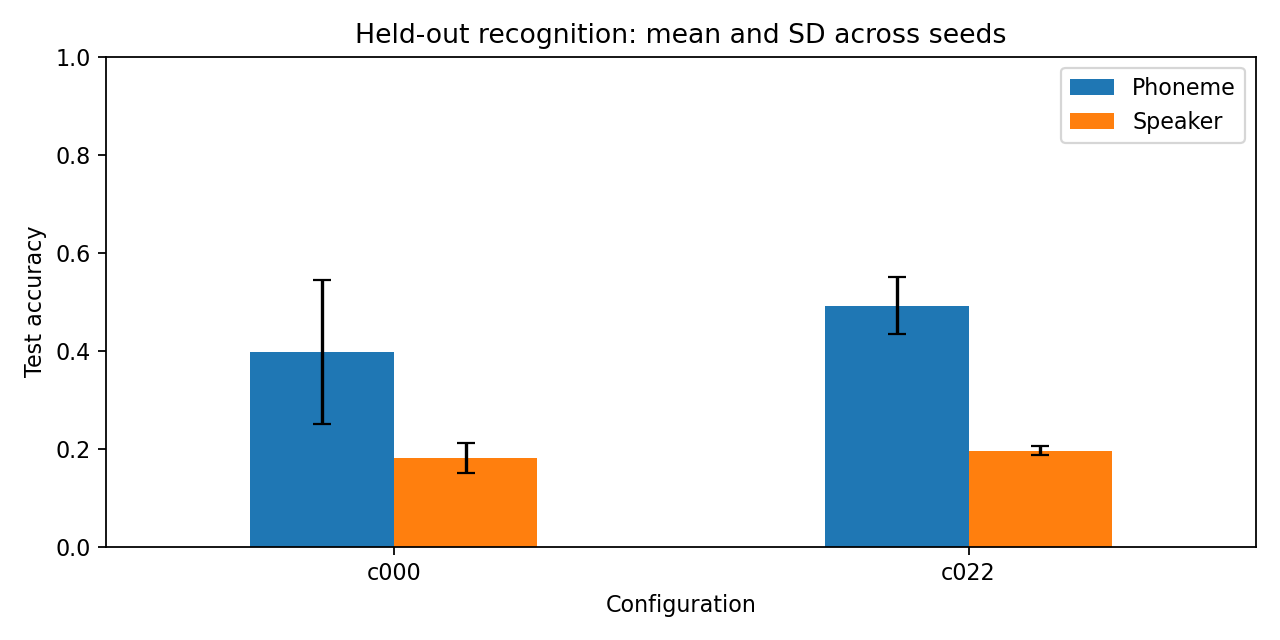

In [6]:
results = pd.read_csv(run_dir / 'test_results.csv')
metrics = ['phoneme_accuracy', 'speaker_accuracy', 'joint_accuracy']
display(results)
display(results.groupby('candidate_id')[metrics].agg(['mean', 'std']))
paired = json.loads((run_dir / 'paired_seed_differences.json').read_text(encoding='utf-8'))
display(pd.DataFrame(paired, index=plan['search']['confirmation_seeds']).rename_axis('seed') * 100)
print('Paired differences above are percentage points: selected configuration minus control.')

fig, ax = plt.subplots(figsize=(8, 4))
summary = results.groupby('candidate_id')[metrics[:2]].mean()
spread = results.groupby('candidate_id')[metrics[:2]].std().fillna(0)
summary.plot.bar(yerr=spread, ax=ax, capsize=4, rot=0)
ax.set(ylim=(0, 1), xlabel='Configuration', ylabel='Test accuracy', title='Held-out recognition: mean and SD across seeds')
ax.legend(['Phoneme', 'Speaker'])
fig.tight_layout()
fig.savefig(run_dir / 'test_comparison.png', dpi=160)
plt.close(fig)
display(Image(filename=str(run_dir / 'test_comparison.png')))

## 7. Inspect learning curves and reload a selected checkpoint

The search preserves per-epoch training and unsupervised validation losses. A saved checkpoint corresponds to minimum validation loss, not maximum category recognition on the test set.

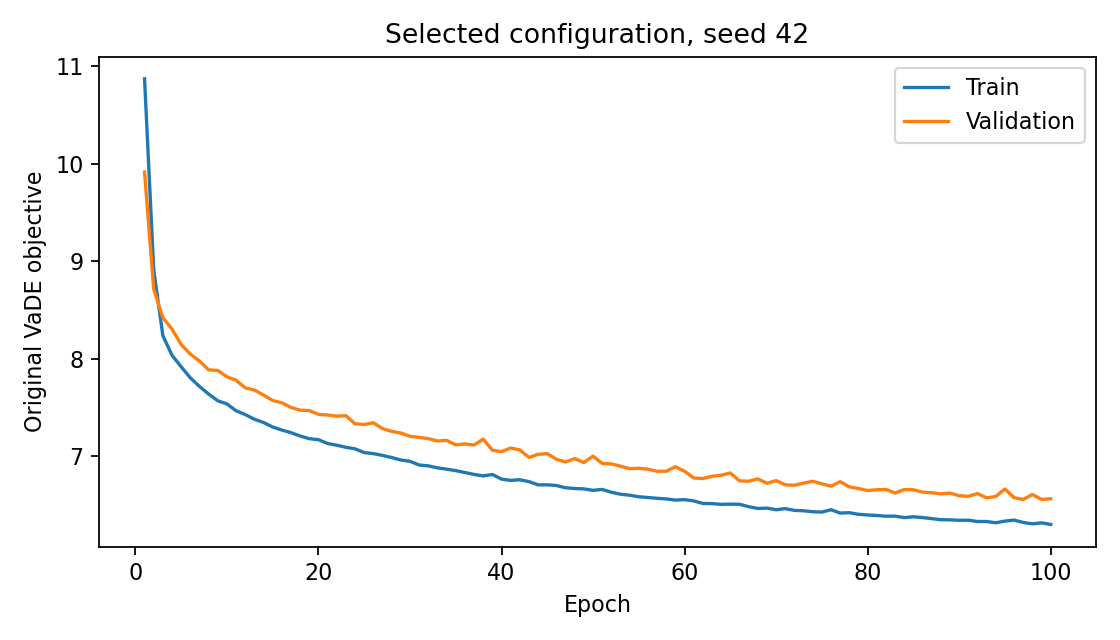

C:\Users\46021\.conda\envs\lffl\Lib\site-packages\torch\_utils.py:831: UserWarning: TypedStorage is deprecated. It will be removed in the future and UntypedStorage will be the only storage class. This should only matter to you if you are using storages directly.  To access UntypedStorage directly, use tensor.untyped_storage() instead of tensor.storage()
  return self.fget.__get__(instance, owner)()


Reloaded model reproduces all saved test predictions.


In [7]:
seed = plan['search']['confirmation_seeds'][0]
trial_dir = run_dir / 'confirm' / f"{selection['winner_id']}_seed_{seed}"
history = pd.read_csv(trial_dir / 'history.csv')
fig, ax = plt.subplots(figsize=(7, 4))
ax.plot(history.epoch, history.train_loss, label='Train')
ax.plot(history.epoch, history.val_loss, label='Validation')
ax.set(xlabel='Epoch', ylabel='Original VaDE objective', title=f"Selected configuration, seed {seed}")
ax.legend()
fig.tight_layout()
fig.savefig(run_dir / 'winner_learning.png', dpi=160)
plt.close(fig)
display(Image(filename=str(run_dir / 'winner_learning.png')))

from src.grid_search import load_neural_checkpoint
from src.config import DataConfig
from src.data import prepare_data
from src.evaluation import predict_neural
from src.training import seed_everything
seed_everything(seed, plan['search']['threads_per_worker'])
model, checkpoint = load_neural_checkpoint(trial_dir / 'best.pt')
trial_config = json.loads((trial_dir / 'config.json').read_text(encoding='utf-8'))
vowels = prepare_data(DataConfig(**plan['search']['base']['data']))
raw, _ = predict_neural(model, 'gmvae', vowels.x['test'], trial_config['training']['batch_size'], seed + 200)
mapping = [np.array(m) for m in checkpoint['label_mappings']]
predicted = np.column_stack([mapping[c][raw[:, c]] for c in range(2)])
saved = pd.read_csv(trial_dir / 'test_predictions.csv')
assert np.array_equal(predicted, saved[['pred_phoneme', 'pred_speaker']].to_numpy())
print('Reloaded model reproduces all saved test predictions.')

## 8. Reuse the winning configuration or extend the grid

The search writes a runnable Python `best_config.py`. It uses the original model's statistical assumptions with the validation-selected neural/training settings. Copy it into `src/configs/` if you want a permanent named configuration.

```bash
python src/train.py --config outputs/neural_grid/RUN_DIRECTORY/best_config.py
python src/train_grid.py --config src/configs/neural_grid.py
python src/train_grid.py --config src/configs/neural_grid.py --resume outputs/neural_grid/RUN_DIRECTORY
```

Edit the grid values in `src/configs/neural_grid.py` for a new search. The supported grid axes are deliberately restricted to neural width/depth, activation, learning rate, and batch size. Statistical-model settings are protected. Completed trials are reused on resume only when the saved plan, CSV hash, and algorithm-source hashes match.

In [8]:
print('Reusable winning config:', run_dir / 'best_config.py')
print('CLI:')
print(f'python src/train.py --config "{run_dir / "best_config.py"}"')
print('Search directory:', run_dir)

Reusable winning config: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\neural_grid\20260924_225129_ccc857\best_config.py
CLI:
python src/train.py --config "E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\neural_grid\20260924_225129_ccc857\best_config.py"
Search directory: E:\SynologyDrive\Documents\research\variation_perceptual_magnet\codes\outputs\neural_grid\20260924_225129_ccc857
